# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [54]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
path = r'C:\Users\luis3\Downloads\RI26A\Recuperacion_Informacion\data\gutenberg_top100'
files = [f for f in os.listdir(path) if f.endswith('.txt')]
corpus = []
titulos = []

for archivo in files:
    with open(os.path.join(path, archivo), 'r', encoding='utf-8', errors='ignore') as f:
        texto = f.read()
    corpus.append(texto)
    titulos.append(archivo)

print(f'Corpus cargado: {len(corpus)} documentos')

Corpus cargado: 103 documentos


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [43]:
# --- TF: frecuencia de términos (conteos crudos) ---
count_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20000
)
matriz_tf = count_vectorizer.fit_transform(corpus)
vocabulario = count_vectorizer.get_feature_names_out()

df_tf = pd.DataFrame(
    matriz_tf.toarray(),
    index=titulos,
    columns=vocabulario
)

print('Matriz TF (frecuencia de términos):')
print(f'Dimensiones: {df_tf.shape}')
df_tf.head()

Matriz TF (frecuencia de términos):
Dimensiones: (103, 20000)


,00,000,10,100,1000,101,102,103,104,105,...,áking,áraw,æneas,élysées,épinay,éponine,íbig,ísip,úlo,über
100_Complete_Works_Shakespeare.txt,0,0,2,4,1,1,1,1,2,1,...,0,0,3,0,0,0,0,0,0,0
1023_Bleak_House.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1080_A_Modest_Proposal.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1184_The_Count_of_Monte_Cristo.txt,0,229,5,17,0,2,2,2,2,2,...,0,0,0,34,85,0,0,0,0,0
11_Alices_Adventures_in_Wonderland.txt,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
# --- DF: Document Frequency (en cuántos documentos aparece cada término) ---
df_freq = (matriz_tf.toarray() > 0).sum(axis=0)
df_df = pd.Series(df_freq, index=vocabulario).sort_values(ascending=False)

print('Top 20 términos por Document Frequency (DF):')
print(df_df.head(20))

Top 20 términos por Document Frequency (DF):
away         103
gutenberg    103
start        103
man          103
end          103
project      103
ebook        103
come         102
make         102
kind         102
long         102
things       102
old          102
work         102
way          102
new          102
people       101
little       101
able         101
life         101
dtype: int64


In [45]:
# --- IDF: Inverse Document Frequency ---
N = len(corpus)
idf_valores = np.log((N + 1) / (df_freq + 1)) + 1  # fórmula sklearn

df_idf = pd.Series(idf_valores, index=vocabulario).sort_values(ascending=False)

print('Top 20 términos con mayor IDF (más raros/específicos):')
print(df_idf.head(20))

Top 20 términos con mayor IDF (más raros/específicos):
zherkóv          4.951244
zeys             4.951244
zverkov          4.951244
cung             4.951244
culay            4.951244
culang           4.951244
curang           4.951244
olympos          4.951244
olivain          4.951244
crupp            4.951244
cruncher         4.951244
supernaturall    4.951244
custome          4.951244
sundalo          4.951244
dacong           4.951244
daang            4.951244
daan             4.951244
cáhoy            4.951244
cromlech         4.951244
crisóstomo       4.951244
dtype: float64


In [46]:
# --- TF-IDF con sklearn ---
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20000,
    sublinear_tf=True
)
matriz_tfidf = tfidf_vectorizer.fit_transform(corpus)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    index=titulos,
    columns=vocab_tfidf
)

print('Matriz TF-IDF:')
print(f'Dimensiones: {df_tfidf.shape}')
df_tfidf.head()

Matriz TF-IDF:
Dimensiones: (103, 20000)


,00,000,10,100,1000,101,102,103,104,105,...,áking,áraw,æneas,élysées,épinay,éponine,íbig,ísip,úlo,über
100_Complete_Works_Shakespeare.txt,0.0,0.000000,0.003468,0.005950,0.003474,0.003089,0.003205,0.003205,0.005139,0.003089,...,0.0,0.0,0.009782,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1023_Bleak_House.txt,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1080_A_Modest_Proposal.txt,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1184_The_Count_of_Monte_Cristo.txt,0.0,0.020559,0.007868,0.014069,0.000000,0.007699,0.007987,0.007987,0.007565,0.007699,...,0.0,0.0,0.000000,0.036644,0.047992,0.0,0.0,0.0,0.0,0.0
11_Alices_Adventures_in_Wonderland.txt,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [47]:
# Comparación TF vs TF-IDF para una palabra de ejemplo
palabra = 'murder'

if palabra in df_tf.columns and palabra in df_tfidf.columns:
    comp = pd.DataFrame({
        'TF':     df_tf[palabra],
        'TF-IDF': df_tfidf[palabra]
    })
    print(f"Comparación TF vs TF-IDF para la palabra '{palabra}':")
    print(comp[comp['TF'] > 0].sort_values('TF-IDF', ascending=False).head(10))
else:
    print(f"La palabra '{palabra}' no está en el vocabulario. Prueba otra.")

Comparación TF vs TF-IDF para la palabra 'murder':
                                          TF    TF-IDF
43_Dr_Jekyll_and_Mr_Hyde.txt              10  0.028105
244_A_Study_in_Scarlet.txt                18  0.025351
1513_Romeo_and_Juliet.txt                 10  0.024424
pg1513.txt                                10  0.023147
27673_Oedipus_King_of_Thebes.txt           6  0.022364
2097_Autobiography_Benjamin_Franklin.txt  10  0.022066
84_Frankenstein.txt                       22  0.020288
pg84.txt                                  22  0.019808
16328_Beowulf.txt                          9  0.017600
174_Picture_of_Dorian_Gray.txt            10  0.017229


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [49]:
# consulta de lo deseado a buscar
CONSULTA = 'Zarathustra'
TOP_N = 10

# Construir el vector de consulta en el mismo espacio TF-IDF
vector_consulta = tfidf_vectorizer.transform([CONSULTA])

# Calcular similitud coseno
similitudes = cosine_similarity(vector_consulta, matriz_tfidf).flatten()

# Ranking
indices_top = similitudes.argsort()[::-1][:TOP_N]

ranking_tfidf = pd.DataFrame({
    'Documento': [titulos[i] for i in indices_top],
    'Score TF-IDF': [similitudes[i] for i in indices_top]
})
ranking_tfidf.index = range(1, TOP_N + 1)
ranking_tfidf.index.name = 'Rank'

print(f"Ranking TF-IDF para: '{CONSULTA}'")
ranking_tfidf

Ranking TF-IDF para: 'Zarathustra'


,Documento,Score TF-IDF
Rank,,
1,1998_Thus_Spake_Zarathustra.txt,0.090244
2,20228_Noli_Me_Tangere.txt,0.016395
3,4300_Ulysses.txt,0.014696
4,4363_Beyond_Good_and_Evil.txt,0.014013
5,45368_Outline_of_History.txt,0.008443
6,pg45368.txt,0.008422
7,pg69093.txt,0.000000
8,pg2701.txt,0.000000
9,pg2641.txt,0.000000


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.
### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [50]:
# --- Paso 1: Tokenización ---
def tokenizar(texto):
    texto = texto.lower()
    tokens = re.findall(r'\b[a-z]+\b', texto)
    stopwords = set([
        'the','a','an','and','or','but','in','on','at','to','for',
        'of','with','by','from','is','was','are','were','be','been',
        'it','its','this','that','as','he','she','they','we','i',
        'his','her','their','our','my','you','your','not','had','have'
    ])
    return [t for t in tokens if t not in stopwords and len(t) > 2]

docs_tokens = [tokenizar(doc) for doc in corpus]
print(f'Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):')
print(docs_tokens[0][:10])

Tokenización lista. Ejemplo (primeros 10 tokens del doc 0):
['start', 'project', 'gutenberg', 'ebook', 'complete', 'works', 'william', 'shakespeare', 'william', 'shakespeare']


In [51]:
# --- Paso 2: Longitudes de documentos y promedio ---
doc_lengths = [len(tokens) for tokens in docs_tokens]
avgdl = sum(doc_lengths) / len(doc_lengths)

print(f'Longitud promedio de documentos: {avgdl:.0f} tokens')
print(f'Doc más corto: {min(doc_lengths)} tokens')
print(f'Doc más largo: {max(doc_lengths)} tokens')

Longitud promedio de documentos: 87872 tokens
Doc más corto: 1503 tokens
Doc más largo: 583706 tokens


In [52]:
# --- Paso 3: TF por documento (conteo de cada término) ---
tf_docs = [Counter(tokens) for tokens in docs_tokens]

print('TF del documento 0 (top 10 palabras):')
print(tf_docs[0].most_common(10))

TF del documento 0 (top 10 palabras):
[('thou', 5932), ('him', 5571), ('will', 5332), ('what', 5135), ('thy', 4353), ('all', 4343), ('shall', 3864), ('thee', 3423), ('king', 3204), ('lord', 3166)]


In [55]:
# --- Paso 4: DF e IDF de BM25 ---
N = len(corpus)

# DF: en cuántos documentos aparece cada término
df_bm25 = Counter()
for tf in tf_docs:
    for term in tf:
        df_bm25[term] += 1

# IDF de BM25: log((N - df + 0.5) / (df + 0.5) + 1)
def idf_bm25(term):
    df = df_bm25.get(term, 0)
    return math.log((N - df + 0.5) / (df + 0.5) + 1)

print('DF e IDF BM25 calculados')
print(f"IDF de 'murder': {idf_bm25('murder'):.4f}")
print(f"IDF de 'said'  : {idf_bm25('said'):.4f}")

DF e IDF BM25 calculados
IDF de 'murder': 0.3071
IDF de 'said'  : 0.0243


In [56]:
# --- Paso 5: Parámetros BM25 ---
k1 = 1.5   # controla la saturación de TF (típico: 1.2 - 2.0)
b  = 0.75  # controla la normalización por longitud (típico: 0.75)

print(f'Parámetros BM25: k1={k1}, b={b}')

Parámetros BM25: k1=1.5, b=0.75


In [57]:
# --- Paso 6: Score BM25 para un documento ---
def score_bm25_doc(query_terms, doc_idx):
    score = 0
    tf = tf_docs[doc_idx]
    dl = doc_lengths[doc_idx]
    for term in query_terms:
        if term not in tf:
            continue
        tf_term = tf[term]
        idf = idf_bm25(term)
        numerador   = tf_term * (k1 + 1)
        denominador = tf_term + k1 * (1 - b + b * dl / avgdl)
        score += idf * (numerador / denominador)
    return score

In [58]:
# --- Paso 7: Score BM25 para todos los documentos ---
def buscar_bm25(consulta, top_n=10):
    query_terms = tokenizar(consulta)
    scores = [
        (i, score_bm25_doc(query_terms, i))
        for i in range(len(corpus))
    ]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_n]

In [59]:
# --- Paso 8: Ranking BM25 ---
resultados_bm25 = buscar_bm25(CONSULTA, TOP_N)

ranking_bm25 = pd.DataFrame({
    'Documento':  [titulos[i] for i, _ in resultados_bm25],
    'Score BM25': [score     for _, score in resultados_bm25]
})
ranking_bm25.index = range(1, TOP_N + 1)
ranking_bm25.index.name = 'Rank'

print(f"Ranking BM25 para: '{CONSULTA}'")
ranking_bm25

Ranking BM25 para: 'Zarathustra'


,Documento,Score BM25
Rank,,
1,1998_Thus_Spake_Zarathustra.txt,6.919200
2,20228_Noli_Me_Tangere.txt,5.535479
3,4300_Ulysses.txt,3.823206
4,4363_Beyond_Good_and_Evil.txt,3.678650
5,45368_Outline_of_History.txt,2.459302
6,pg45368.txt,2.448132
7,100_Complete_Works_Shakespeare.txt,0.000000
8,1023_Bleak_House.txt,0.000000
9,1080_A_Modest_Proposal.txt,0.000000


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

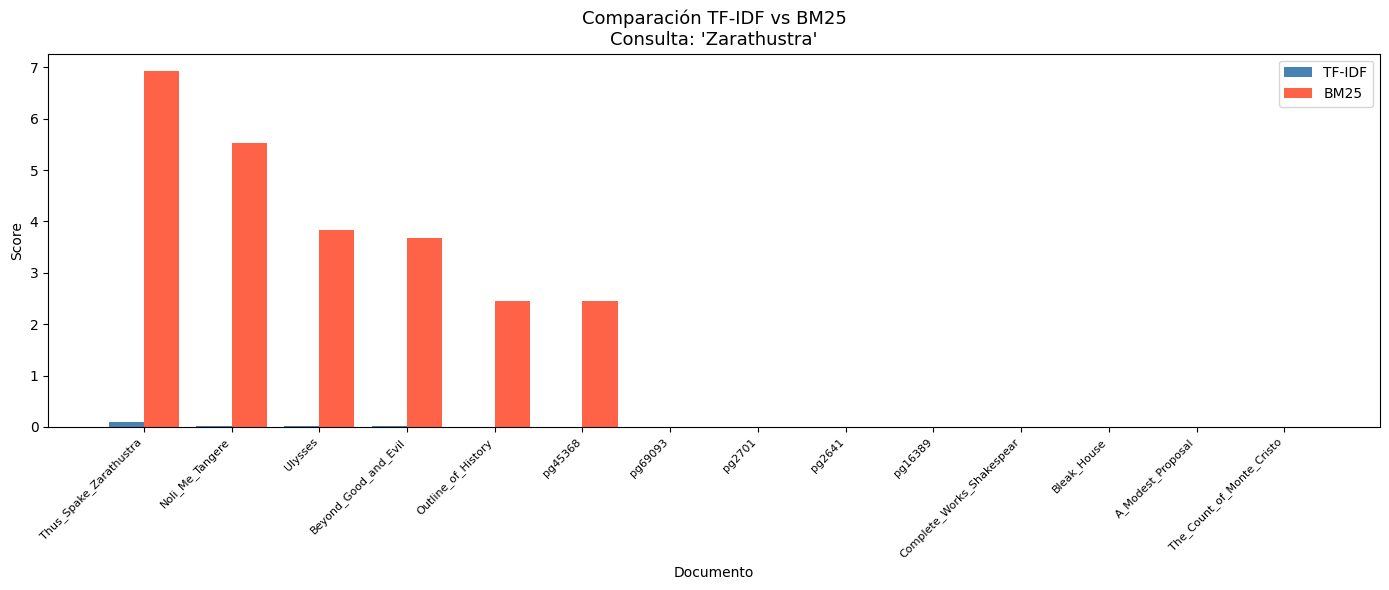

In [60]:
# Unir rankings por documento para comparar
top_docs_tfidf = ranking_tfidf['Documento'].tolist()
top_docs_bm25  = ranking_bm25['Documento'].tolist()
todos_docs     = list(dict.fromkeys(top_docs_tfidf + top_docs_bm25))  # sin duplicados

# Scores TF-IDF para todos los docs del top combinado
scores_tfidf_dict = dict(zip(ranking_tfidf['Documento'], ranking_tfidf['Score TF-IDF']))
scores_bm25_dict  = dict(zip(ranking_bm25['Documento'],  ranking_bm25['Score BM25']))

scores_tfidf_plot = [scores_tfidf_dict.get(d, 0) for d in todos_docs]
scores_bm25_plot  = [scores_bm25_dict.get(d, 0)  for d in todos_docs]

# Etiquetas cortas para el gráfico
labels = [d.replace('.txt', '').split('_', 1)[-1][:25] for d in todos_docs]

x = np.arange(len(todos_docs))
ancho = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
barras1 = ax.bar(x - ancho/2, scores_tfidf_plot, ancho, label='TF-IDF', color='steelblue')
barras2 = ax.bar(x + ancho/2, scores_bm25_plot,  ancho, label='BM25',   color='tomato')

ax.set_title(f"Comparación TF-IDF vs BM25\nConsulta: '{CONSULTA}'", fontsize=13)
ax.set_xlabel('Documento')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
# Tabla comparativa de rankings
df_comparacion = pd.DataFrame({
    'Rank TF-IDF': range(1, TOP_N + 1),
    'Doc TF-IDF':  ranking_tfidf['Documento'].values,
    'Score TF-IDF': ranking_tfidf['Score TF-IDF'].round(4).values,
    'Rank BM25':   range(1, TOP_N + 1),
    'Doc BM25':    ranking_bm25['Documento'].values,
    'Score BM25':  ranking_bm25['Score BM25'].round(4).values,
})

print('Comparación de rankings:')
df_comparacion

Comparación de rankings:


,Rank TF-IDF,Doc TF-IDF,Score TF-IDF,Rank BM25,Doc BM25,Score BM25
0,1,1998_Thus_Spake_Zarathustra.txt,0.0902,1,1998_Thus_Spake_Zarathustra.txt,6.9192
1,2,20228_Noli_Me_Tangere.txt,0.0164,2,20228_Noli_Me_Tangere.txt,5.5355
2,3,4300_Ulysses.txt,0.0147,3,4300_Ulysses.txt,3.8232
3,4,4363_Beyond_Good_and_Evil.txt,0.0140,4,4363_Beyond_Good_and_Evil.txt,3.6787
4,5,45368_Outline_of_History.txt,0.0084,5,45368_Outline_of_History.txt,2.4593
5,6,pg45368.txt,0.0084,6,pg45368.txt,2.4481
6,7,pg69093.txt,0.0000,7,100_Complete_Works_Shakespeare.txt,0.0000
7,8,pg2701.txt,0.0000,8,1023_Bleak_House.txt,0.0000
8,9,pg2641.txt,0.0000,9,1080_A_Modest_Proposal.txt,0.0000
9,10,pg16389.txt,0.0000,10,1184_The_Count_of_Monte_Cristo.txt,0.0000
